# Proyecto Clasificación de texto

Bienvenidos al proyecto del curso. El presente proyecto consiste en una competencia académica en la que participarán grupos de todas las secciones. El desafío propuesto consiste en desarrollar un sistema de clasificación de textos según su década de origen. El objetivo principal es diseñar un modelo capaz de predecir la década en la que fue escrito un párrafo determinado.

La competencia se divide en dos etapas. En la primera, los participantes deberán emplear técnicas tradicionales de aprendizaje automático, sin recurrir al uso de redes neuronales ni arquitecturas profundas. Esta competencia SOLO corresponde a la primera epata. Posteriormente se le dará mas información sobre la segunda.

Description
Debe diseñar y entrenar un modelo que dado un parágrafo pueda detectar la década de origen del texto

Limitaciones No se permite el uso de técnicas de aprendizaje profundo, especialmente el uso de modelos de lenguaje de tipo transformer. La competencia se deberá realizar en su totalidad usando una combinación de técnicas tradicionales de aprendizaje de maquina y técnicas de PLN.

Evaluación
Las respuestas serán evaluados usando accuracy (puede asumir que no hay desbalance en el dataset de evaluación).

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
df = pd.read_csv("./train.csv")
df_train = pd.read_csv("./eval.csv")
df.head()

,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\nlos que panden macho ; y \notros en l...,166


# EDA

In [3]:
df.columns

Index(['text', 'decade'], dtype='object')

In [4]:
df.shape

(31403, 2)

In [5]:
print(df["text"][0])


Honorarias ¡jubiladas. 57 
dit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 
pag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len 
nes parece que aísilte, O ayuda Calsiodoro 
lib,6.epuft.s 2.Donde * llama Ocloso CINGV- y 19 


In [6]:
# Ver longitudes
df["text"].apply(len).describe()

count    31403.000000
mean       520.568290
std        530.947792
min        120.000000
25%        182.000000
50%        315.000000
75%        643.000000
max       7418.000000
Name: text, dtype: float64

Hay textos medianamente largos lo cual es bueno, pero hay textos muy largos. El problema potencial es que los textos largos dominen el modelo, se podría limitar a maximo 2000 caracteres lo que evita outliers extremos como un intento de mejora al modelo

In [7]:
# ver clases (decadas)
df["decade"].value_counts()

decade
160    848
172    842
155    836
170    833
167    831
178    831
154    830
157    827
163    827
180    825
168    822
175    817
171    816
165    814
151    812
188    809
179    809
182    808
162    808
174    807
164    804
185    803
184    802
173    802
159    802
181    795
183    794
156    792
161    787
187    787
150    786
152    785
177    782
166    779
158    778
153    775
186    773
169    771
176    754
Name: count, dtype: int64

Todas las clases tienen 750-850 ejemplos. Hay un dataset balanceado

In [9]:
# Hay textos vacios?
rta1 = (df["text"].str.strip() == "").sum()
print (f"Numero de textos vacios: {rta1}")
# Hay textos muy cortos?
rta2 = df["text"].apply(len).sort_values().head(10)
print(rta2)

Numero de textos vacios: 0
6983     120
21031    120
4336     120
12772    120
14600    120
14579    120
11453    120
21881    120
6393     120
4314     120
Name: text, dtype: int64


No hay textos vacíos, no hay textos demasiado cortos que sean basura, todo tiene minimo contenido util

## Preprocesamiento del texto

Se realizó una limpieza ligera del texto con el objetivo de reducir el ruido presente en el dataset sin eliminar información relevante para la clasificación. Específicamente, se aplicaron las siguientes transformaciones:

* Conversión de todo el texto a minúsculas para evitar duplicidad de tokens por diferencias de capitalización.

* Eliminación de saltos de línea y normalización de espacios, con el fin de evitar la generación de tokens irrelevantes.

* Remoción de caracteres especiales y símbolos no alfabéticos, los cuales provienen principalmente de errores de digitalización (OCR) y no aportan valor semántico al modelo.

Esta limpieza se realizó de forma conservadora, evitando aplicar técnicas más agresivas como stemming o lematización, ya que podrían distorsionar aún más las palabras debido a la naturaleza ruidosa y antigua del corpus.

In [ ]:
# Limpieza en los saltos de linea y espacios extra existentes
df["text"] = df["text"].str.replace("\n", " ")
df["text"] = df["text"].str.replace(r"\s+", " ", regex=True)

In [22]:
import re

def limpiar_texto(texto):
    texto = texto.lower()
    
    # quitar símbolos raros (deja letras y espacios)
    texto = re.sub(r'[^a-záéíóúñü\s]', '', texto)
    
    return texto

df["text"] = df["text"].apply(limpiar_texto)

Debido al ruido del dataset (OCR y español antiguo), técnicas como stemming no fueron utilizadas, ya que distorsionan aún más las palabras.

Se va a evaluar si el uso de Bolsa de Palabras BOW es el método correcto para este modelo

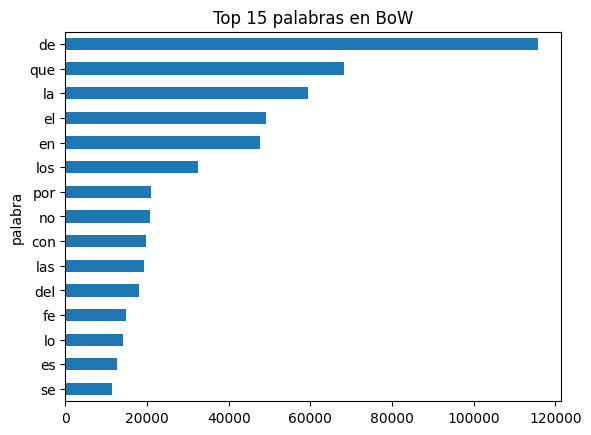

In [23]:
# Evaluar uso de Bag of words
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

vectorizador_bow = CountVectorizer(max_features=15)

X_bow = vectorizador_bow.fit_transform(df['text'])

counts = X_bow.toarray().sum(axis=0)
words = vectorizador_bow.get_feature_names_out()

# DataFrame para graficar
df_bow = pd.DataFrame({
    'palabra': words,
    'conteo': counts
}).sort_values('conteo', ascending=True)

# Gráfico
df_bow.plot.barh(x='palabra', y='conteo', legend=False)
plt.title("Top 15 palabras en BoW")
plt.show()

El análisis de frecuencia mediante Bag of Words muestra que las palabras más comunes corresponden principalmente a palabras funcionales del idioma (como ‘de’, ‘que’, ‘la’), las cuales aparecen en la mayoría de los documentos independientemente de la década. Estas palabras no aportan valor discriminativo para la tarea de clasificación, ya que no permiten diferenciar entre estilos de escritura de distintas épocas.Esto evidencia una limitación del enfoque Bag of Words, ya que tiende a priorizar términos frecuentes pero poco informativos

Para superar esta limitación, se utilizó TF-IDF, que penaliza palabras comunes y resalta términos más representativos de cada documento. Debido a la presencia de ruido y variaciones ortográficas en el dataset, se optó por una representación basada en n-gramas de caracteres en lugar de palabras completas, ya que esta permite capturar patrones más robustos.

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_char = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3,5),
    max_features=30000,
    strip_accents='unicode' # Ayuda con caracteres raros, quita tildes automaticamente
)

X_tfidf_char = tfidf_char.fit_transform(df['text'])



In [33]:
print("Vocabulario:")
print(tfidf_char.get_feature_names_out())

Vocabulario:
[' a ' ' aa' ' aa ' ... 'zun' 'zur' 'zy ']


In [34]:
print("Vector TF-IDF del documento 1:")
print(X_tfidf_char[0].toarray())

Vector TF-IDF del documento 1:
[[0. 0. 0. ... 0. 0. 0.]]


In [35]:
doc_vector = X_tfidf_char[0].toarray().flatten()

df_importancia = pd.DataFrame({
    "ngram": tfidf_char.get_feature_names_out(),
    "peso": doc_vector
})

df_importancia = df_importancia.sort_values(by="peso", ascending=False)

df_importancia.head(10)

,ngram,peso
15861,ifce,0.105753
4495,ste,0.105563
7843,bila,0.104293
27983,ubil,0.104120
2698,jub,0.103283
16376,ilte,0.102645
24405,ratia,0.102034
17648,jub,0.101446
18758,lsio,0.101160
27563,tpr,0.098212


A diferencia del enfoque Bag of Words, la representación TF-IDF basada en n-gramas de caracteres permite identificar patrones más específicos del contenido, incluso en presencia de ruido y variaciones ortográficas

Se observan fragmentos como ‘jub’, ‘bila’ o ‘ubil’, los cuales corresponden a raíces de palabras relevantes dentro del corpus, evidenciando que el modelo logra capturar información semántica parcial.

Este enfoque resulta especialmente adecuado para el dataset, ya que permite manejar errores de digitalización y variaciones del lenguaje sin depender de palabras exactas.